In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load from excel
db_main = pd.read_excel(
    'C:/Users/sigzu/OneDrive/Dokumenter/Andre Dokumenter/Billettkontroll data/Billettkontroll data.xlsx')
db_aanerud = pd.read_excel(
    'C:/Users/sigzu/OneDrive/Dokumenter/Andre Dokumenter/Billettkontroll data/Billettkontroll data-aanerud.xlsx')


In [2]:
db_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Linje                           268 non-null    object        
 1   Vogn                            228 non-null    object        
 2   Dato                            268 non-null    datetime64[ns]
 3   Klokke                          268 non-null    object        
 4   Fra                             268 non-null    object        
 5   Til                             268 non-null    object        
 6   Fullt?                          268 non-null    object        
 7   Sjekket?                        268 non-null    object        
 8   Sjekket etter                   29 non-null     object        
 9   Merknad                         78 non-null     object        
 10  Fullt? = Kun ståplasser igjen?  0 non-null      float64       
dtypes: dat

In [3]:
db_aanerud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Linje     44 non-null     object        
 1   Vogn      43 non-null     object        
 2   Dato      44 non-null     datetime64[ns]
 3   Klokke    44 non-null     object        
 4   Fra       44 non-null     object        
 5   Til       44 non-null     object        
 6   Fullt?    44 non-null     object        
 7   Sjekket?  44 non-null     object        
 8   Merknad   14 non-null     object        
dtypes: datetime64[ns](1), object(8)
memory usage: 3.2+ KB


In [4]:
db = pd.concat([db_main, db_aanerud], ignore_index=True)
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Linje                           312 non-null    object        
 1   Vogn                            271 non-null    object        
 2   Dato                            312 non-null    datetime64[ns]
 3   Klokke                          312 non-null    object        
 4   Fra                             312 non-null    object        
 5   Til                             312 non-null    object        
 6   Fullt?                          312 non-null    object        
 7   Sjekket?                        312 non-null    object        
 8   Sjekket etter                   29 non-null     object        
 9   Merknad                         92 non-null     object        
 10  Fullt? = Kun ståplasser igjen?  0 non-null      float64       
dtypes: dat

# Converting old norwegian column names to english standard

In [5]:
db = db.rename(columns={
    'Linje': 'line',
    'Vogn': 'wagon',
    'Dato': 'date',
    'Klokke': 'time',
    'Fra': 'departure_station',
    'Til': 'arrival_station',
    'Fullt?': 'only_standing',
    'Sjekket?': 'checked',
    'Sjekket etter': 'checked_after',
    'Merknad': 'notes',
})

db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   line                            312 non-null    object        
 1   wagon                           271 non-null    object        
 2   date                            312 non-null    datetime64[ns]
 3   time                            312 non-null    object        
 4   departure_station               312 non-null    object        
 5   arrival_station                 312 non-null    object        
 6   only_standing                   312 non-null    object        
 7   checked                         312 non-null    object        
 8   checked_after                   29 non-null     object        
 9   notes                           92 non-null     object        
 10  Fullt? = Kun ståplasser igjen?  0 non-null      float64       
dtypes: dat

# Cleaning and engineering the features

In [6]:
db = db.drop(columns=['Fullt? = Kun ståplasser igjen?'])

In [7]:
# Convert all column names to lowercase
db.columns = db.columns.str.lower()

# Replace space with underscore in column names
db.columns = db.columns.str.replace(' ', '_')

# Remove special characters from column names
db.columns = db.columns.str.replace(r'[?]', '', regex=True)

In [8]:
# Date convert to discrete features
db['day'] = db['date'].dt.day
db['month'] = db['date'].dt.month
db['year'] = db['date'].dt.year
db['weekday'] = db['date'].dt.weekday
db['weekofyear'] = db['date'].dt.isocalendar().week

# Remove the original date column
db = db.drop(columns=['date'])

In [9]:
# Convert "klokke" to datetime
db['time'] = pd.to_datetime(db['time'], format='%H:%M:%S', errors='coerce')

# Convert departure time to discrete features
db['hour'] = db['time'].dt.hour
db['minute'] = db['time'].dt.minute

# Remove the original time column
db = db.drop(columns=['time'])

In [10]:
# lower all string values in the dataframe
for col in db.select_dtypes(include=['object']).columns:
    db[col] = db[col].str.lower()

# Spaces become non if end of string
for col in db.select_dtypes(include=['object']).columns:
    db[col] = db[col].str.strip()

In [11]:
# ja/nei -> ja and nei/ja -> ja in "sjekket" column
db['checked'] = db['checked'].replace({'ja/nei': 'ja', 'nei/ja': 'ja'})

In [12]:
# If 'noe' in 'fullt' column, replace with 'nei'
db['only_standing'] = db['only_standing'].replace({'noe': 'nei'})

In [13]:
db.head()

,line,wagon,departure_station,arrival_station,only_standing,checked,checked_after,notes,day,month,year,weekday,weekofyear,hour,minute
0,l12,fremst,eidsvoll,oslo lufthavn,nei,nei,NaN,NaN,25,9,2022,6,38,11,30
1,r10,bakerst,oslo lufthavn,eidsvoll,ja,ja,NaN,NaN,25,9,2022,6,38,21,59
2,l12,fremst,eidsvoll,nationaltheatret,ja,nei,NaN,NaN,26,9,2022,0,39,9,30
3,l12,bakerst,nationaltheatret,eidsvoll,ja,nei,NaN,NaN,26,9,2022,0,39,13,48
4,r11,fremst,eidsvoll,oslo lufthavn,nei,ja,NaN,sjekket med en gang,27,9,2022,1,39,6,0


### Convert "sjekket etter" to something useful

In [14]:
# TODO implement
# Remove for now
db = db.drop(columns=['checked_after'])

In [15]:
# Converting all strings to numumeric values
categories = {}
for col in db.select_dtypes(include=['object']).columns:
    cats = pd.Categorical(db[col])
    categories[col] = cats
    print(cats.categories)
    db[col] = cats.codes

Index(['l1', 'l12', 'l14', 'l2', 'r10', 'r11', 'r12', 'r13', 'r14', 'r21',
       'r22', 'r23', 're10', 're11'],
      dtype='object')
Index(['bakerst', 'fremst', 'midten'], dtype='object')
Index(['eidsvoll', 'lillestrøm', 'lysaker', 'lørenskog', 'nationaltheatret',
       'oslo lufthavn', 'oslo s', 'skarnes', 'ski', 'skøyen'],
      dtype='object')
Index(['eidsvoll', 'hamar', 'jessheim', 'kongsvinger', 'lillestrøm', 'lysaker',
       'nationaltheatret', 'oslo lufthavn', 'oslo s', 'skarnes', 'ski',
       'skøyen', 'årnes'],
      dtype='object')
Index(['ja', 'nei'], dtype='object')
Index(['ja', 'nei'], dtype='object')
Index(['12 min forsinket', '15 min forsinket', '20 min forsinket',
       '3 min forsinket inn til oslo s', '5 vogner', '7 min forsinket',
       'annerledes avgangstid', 'ble sjekket med en gang toget reiste',
       'ble sjekket på seterstøa, nettsiden sa det var liten sannsynlighet',
       'ble sjekket rett før seterstøa. nettsiden sa liten sannsynlighet',
       'br

In [16]:
db = db.fillna(-1)

In [17]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   line               312 non-null    int8  
 1   wagon              312 non-null    int8  
 2   departure_station  312 non-null    int8  
 3   arrival_station    312 non-null    int8  
 4   only_standing      312 non-null    int8  
 5   checked            312 non-null    int8  
 6   notes              312 non-null    int8  
 7   day                312 non-null    int32 
 8   month              312 non-null    int32 
 9   year               312 non-null    int32 
 10  weekday            312 non-null    int32 
 11  weekofyear         312 non-null    UInt32
 12  hour               312 non-null    int32 
 13  minute             312 non-null    int32 
dtypes: UInt32(1), int32(6), int8(7)
memory usage: 11.1 KB


# Creating test and train datasets

In [18]:
# Drop irrelevant columns
db = db.drop(columns=['wagon'])
db = db.drop(columns=['notes'])

In [19]:
x = db.drop(columns=['checked'], axis=1)
y = db['checked']
x.head()

,line,departure_station,arrival_station,only_standing,day,month,year,weekday,weekofyear,hour,minute
0,1,0,7,1,25,9,2022,6,38,11,30
1,4,5,0,0,25,9,2022,6,38,21,59
2,1,0,6,0,26,9,2022,0,39,9,30
3,1,4,0,0,26,9,2022,0,39,13,48
4,5,0,7,1,27,9,2022,1,39,6,0


In [34]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_test)

     line  departure_station  arrival_station  only_standing  day  month  \
228    12                  0                5              0   25      8   
9       4                  0                6              0   29      9   
57      8                  6                9              1   18      1   
60     12                  0                6              1   24      1   
25      1                  5                0              1   22     10   
..    ...                ...              ...            ...  ...    ...   
196     8                  6                9              0   28      2   
211     8                  7                6              1   24     11   
225     6                  9                0              0   20      8   
109    12                  6                0              0   17      3   
114    12                  0                8              0   29      3   

     year  weekday  weekofyear  hour  minute  
228  2025        0          35     6    

# Create models and test

In [21]:
import xgboost as xgb

model = xgb.XGBClassifier()
model.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# Test model

In [22]:
preds = model.predict(x_test)
print(preds)

[1 1 1 0 1 1 0 1 0 1 0 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1
 1 1 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 1 0 1]


In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true=y_test, y_pred=preds)
print(f"Accuracy: {accuracy * 100.0 :.2f}")

Accuracy: 77.78


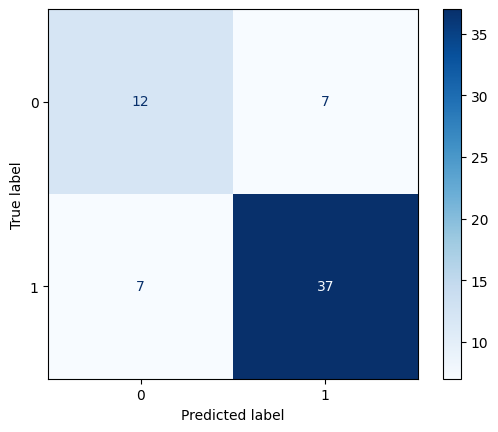

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
disp.plot(cmap="Blues")

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

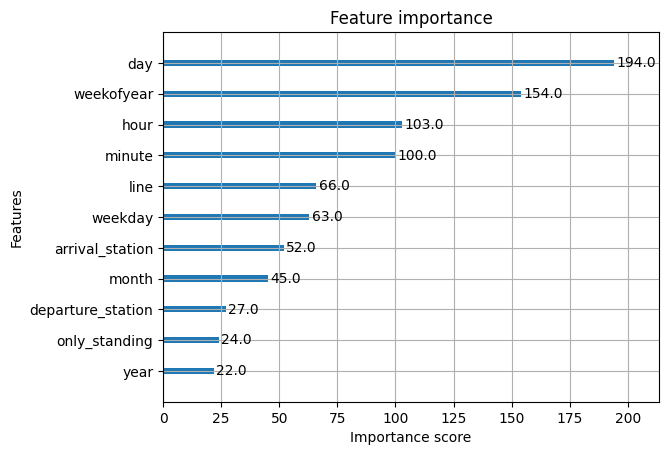

In [25]:
xgb.plot_importance(model)

## Model 2 - Model 1 with Optuna

In [26]:
import optuna as opt


def objective(trial):
    """The objective is to find the best parameters for the most accuracy in the model"""

    params = {
        'max_depth': trial.suggest_int('max_depth', 1, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'min_child_weight': trial.suggest_int('min_child_weight', 0, 10),
        'gamma': trial.suggest_float('gamma', 1e-8, 1e+3),
        'subsample': trial.suggest_float('subsample', 0.01, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.01, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0),
        'eval_metric': 'mlogloss'
    }

    # Fit the model
    optuna_model = xgb.XGBClassifier(**params)
    optuna_model.fit(x_train, y_train)

    # Make predictions
    y_pred = optuna_model.predict(x_test)

    # Evaluate predictions
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy


study = opt.create_study(direction="maximize")
study.optimize(objective, n_trials=750)

C:\Users\sigzu\miniconda3\envs\ticket-inspection-ai-2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-10-03 23:06:44,041] A new study created in memory with name: no-name-0830fe53-2da3-40f2-a811-d0d4fbc3f6f0
[I 2025-10-03 23:06:44,101] Trial 0 finished with value: 0.6984126984126984 and parameters: {'max_depth': 4, 'learning_rate': 0.045507612201386494, 'n_estimators': 444, 'min_child_weight': 10, 'gamma': 396.1065819465829, 'subsample': 0.4753783883160052, 'colsample_bytree': 0.6250903136734668, 'reg_alpha': 0.05467330351077471, 'reg_lambda': 0.2803508602274148}. Best is trial 0 with value: 0.6984126984126984.
[I 2025-10-03 23:06:44,146] Trial 1 finished with value: 0.6984126984126984 and parameters: {'max_depth': 2, 'learning_rate': 0.1414600167948182, 'n_estimators': 301, 'min_child_weight': 1, 'gamma':

In [27]:
bparams = study.best_params
model_2 = xgb.XGBClassifier(**bparams)
model_2.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5950333673905429
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [28]:
preds_2 = model_2.predict(x_test)

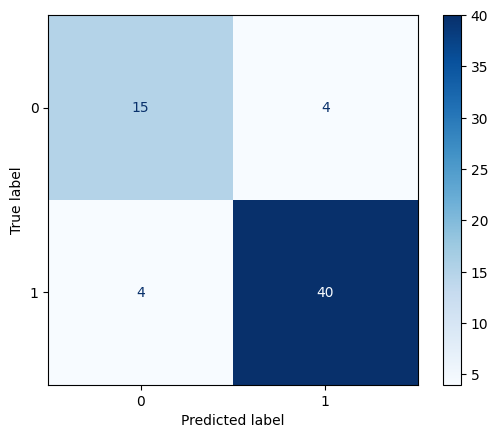

In [29]:
cm = confusion_matrix(y_true=y_test, y_pred=preds_2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_2.classes_)

disp.plot(cmap='Blues')

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

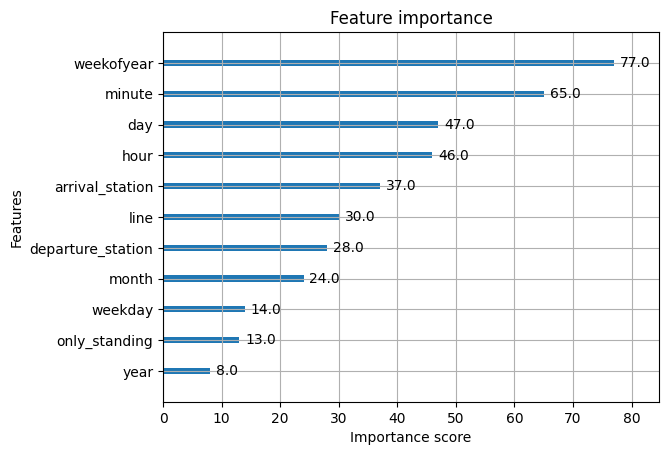

In [30]:
xgb.plot_importance(model_2)

In [31]:
accuracy_2 = accuracy_score(y_true=y_test, y_pred=preds_2)
print(f"Accuracy: {accuracy_2 * 100.0 :.2f}")

Accuracy: 87.30


# Save the best model

In [33]:
import os
import pickle
from datetime import UTC, datetime

# Model 2 will probably always be the best out of these two
dir_path = f"../models/{datetime.now(UTC).strftime("%Y%m%dT%H%M%S%z")}"
os.mkdir(dir_path)
model_2.save_model(f'{dir_path}/ticket-inspection-ai-model-{datetime.now(UTC).strftime("%Y%m%dT%H%M%S%z")}.pkl')

# Save categories
os.mkdir(dir_path + "/categories")
for col, cats in categories.items():
    with open(f'{dir_path}/categories/{col}.pkl', 'wb') as f:
        pickle.dump(cats, f)

C:\Users\sigzu\miniconda3\envs\ticket-inspection-ai-2\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [23:14:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
